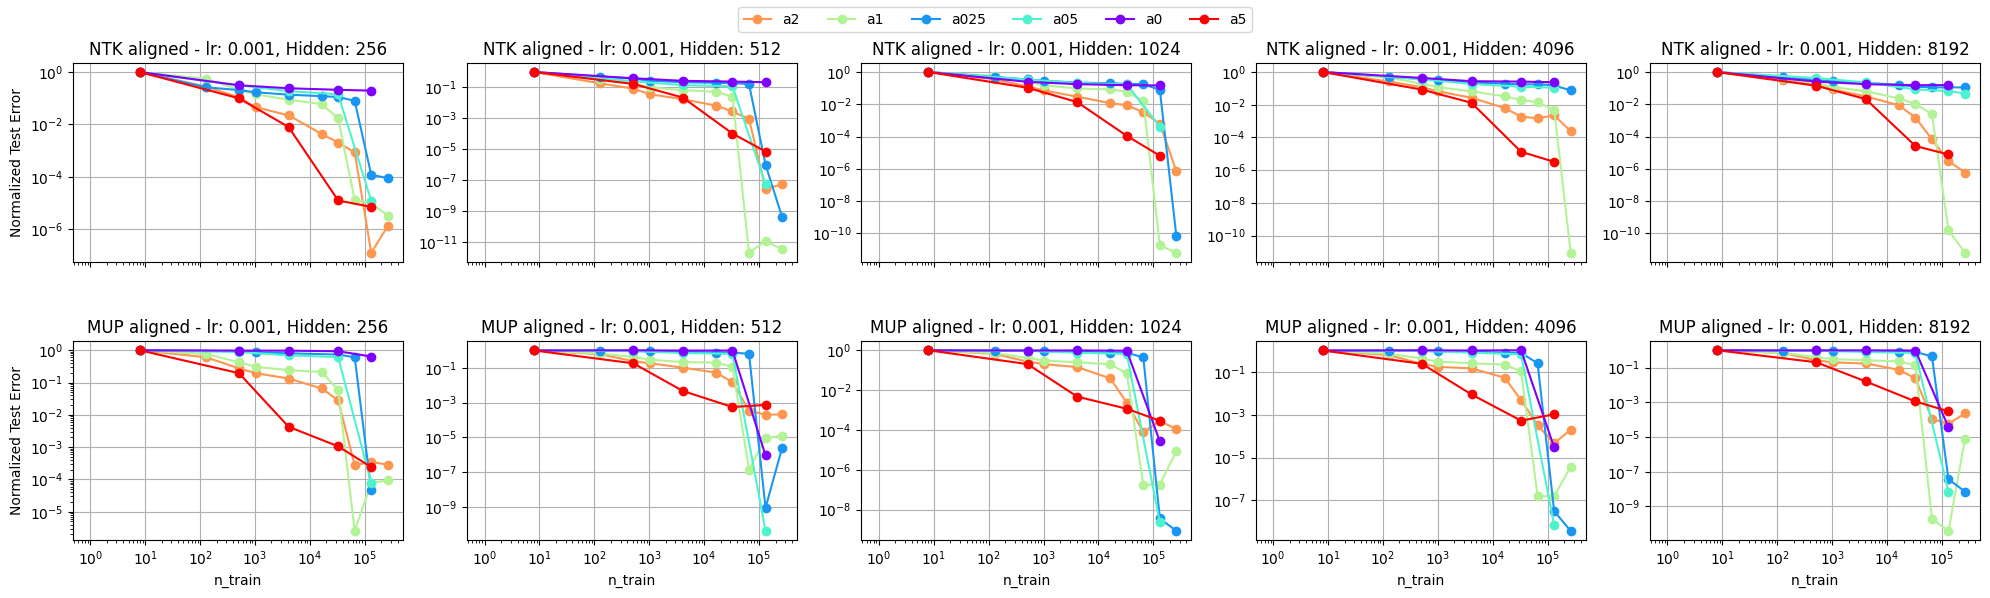

In [3]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the paths to your results directories
standard_results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d30_hidden256_ntk_al_2702"
mup_results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d30_hidden256_mup_al_2702"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = ""  # e.g., "my_plot.png"

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load both sets of results
standard_results = load_results(standard_results_directory)
mup_results = load_results(mup_results_directory)

if not standard_results:
    print("No standard results loaded. Please check the directory path.")
if not mup_results:
    print("No MUP results loaded. Please check the directory path.")

# ======= FILTER FOR DEPTH 1 NETWORKS =======
standard_results_depth1 = [r for r in standard_results if r.get("depth") == 1]
mup_results_depth1 = [r for r in mup_results if r.get("depth") == 1]

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from both standard and MUP results
for r in standard_results_depth1 + mup_results_depth1:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

unique_lr = sorted(lr_set)
unique_hidden = sorted(hidden_set)
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Filter for 'a' datasets

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 5 (assuming a0 to a5 range)
                position = min(1.0, max(0.0, num / 5.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]  # Using final_train_error as per original code
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a5 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group both sets of results
standard_grouped = group_results(standard_results_depth1)
mup_grouped = group_results(mup_results_depth1)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row pair is a learning rate (standard above, MUP below)
n_rows = 2 * len(unique_lr)  # Two rows per learning rate (standard + MUP)
n_cols = len(unique_hidden)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=False)

# Ensure axes is a 2D array
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = np.array([[ax] for ax in axes])

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(unique_lr):
    for j, hs in enumerate(unique_hidden):
        # Calculate row indices for standard and MUP plots
        standard_row = 2 * i
        mup_row = 2 * i + 1
        
        # Get the axes for standard and MUP plots
        ax_standard = axes[standard_row, j]
        ax_mup = axes[mup_row, j]
        
        # Standard plot
        data_dict = standard_grouped[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from viridis map
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax_standard.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # MUP plot - FIXED VERSION WITH CONSISTENT NORMALIZATION
        data_dict = mup_grouped[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled - FIXED: now consistent with NTK plot
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from viridis map
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                ax_mup.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color
                )
        
        # Set scales, labels, title for standard plot
        ax_standard.set_xscale("log")
        ax_standard.set_yscale("log")
        ax_standard.set_title(f"NTK aligned - lr: {lr}, Hidden: {hs}")
        ax_standard.grid(True)
        
        # Only add x-label to bottom row
        if i == len(unique_lr) - 1:
            ax_mup.set_xlabel("n_train")
        
        # Set y-axis label based on normalization
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax_standard.set_ylabel(y_label)
            ax_mup.set_ylabel(y_label)
        
        # Set scales, labels, title for MUP plot
        ax_mup.set_xscale("log")
        ax_mup.set_yscale("log")
        ax_mup.set_title(f"MUP aligned - lr: {lr}, Hidden: {hs}")
        ax_mup.grid(True)

# Create a global legend above the subplots
fig.legend(
    legend_handles.values(), 
    legend_handles.keys(), 
    loc="upper center", 
    ncol=min(len(legend_handles), 6)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4)  # Make room for the legend and between rows

if save_fig_path:
    plt.savefig(save_fig_path)
    print("Figure saved to", save_fig_path)
else:
    plt.show()

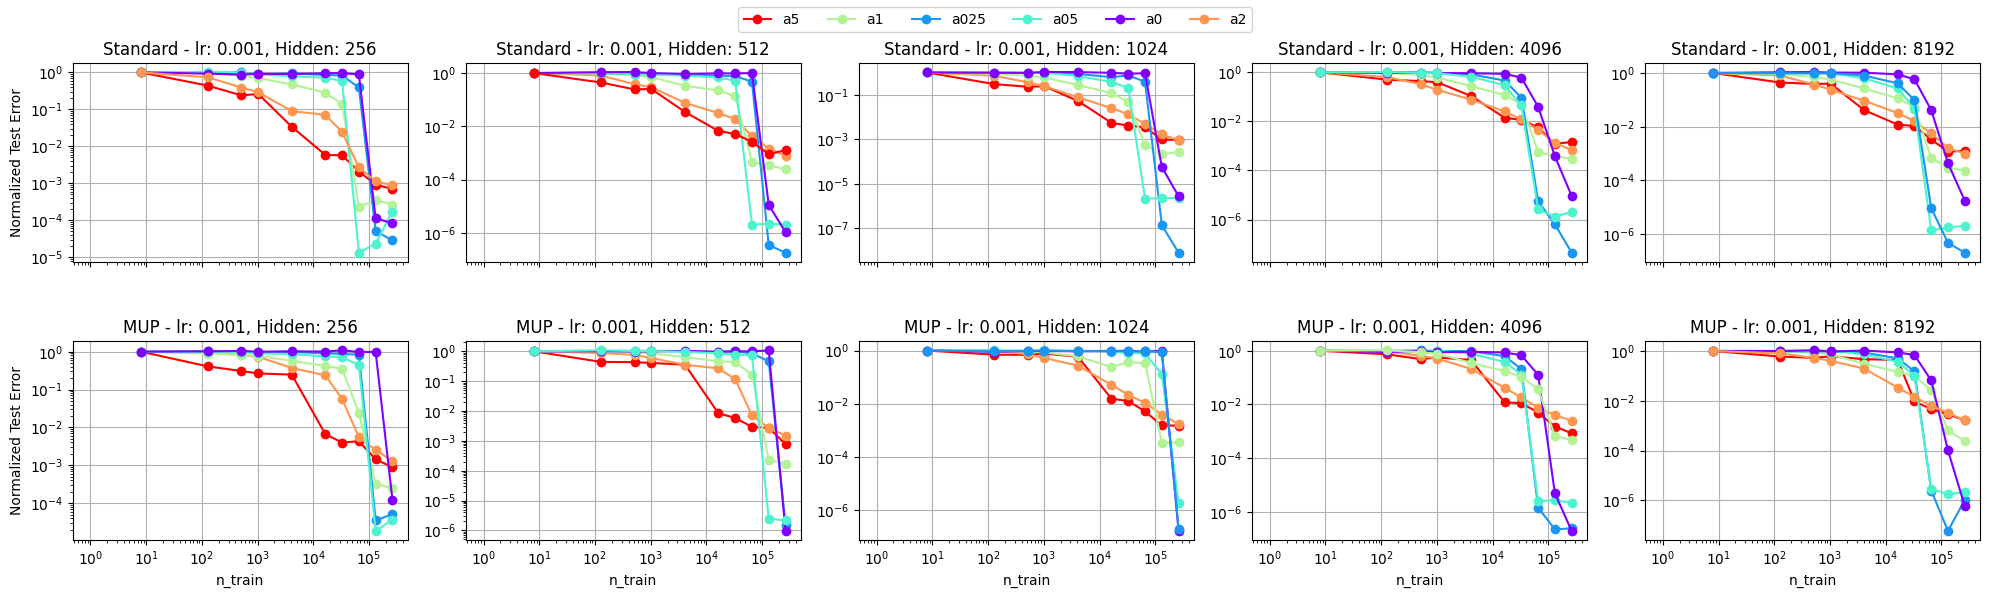

In [10]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the paths to your results directories
standard_results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d50_hidden256_standard_2502"
mup_results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d50_hidden256_mup_2502"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = ""  # e.g., "my_plot.png"

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load both sets of results
standard_results = load_results(standard_results_directory)
mup_results = load_results(mup_results_directory)

if not standard_results:
    print("No standard results loaded. Please check the directory path.")
if not mup_results:
    print("No MUP results loaded. Please check the directory path.")

# ======= FILTER FOR DEPTH 1 NETWORKS =======
standard_results_depth1 = [r for r in standard_results if r.get("depth") == 1]
mup_results_depth1 = [r for r in mup_results if r.get("depth") == 1]

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from both standard and MUP results
for r in standard_results_depth1 + mup_results_depth1:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

unique_lr = sorted(lr_set)
unique_hidden = sorted(hidden_set)
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Filter for 'a' datasets

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 5 (assuming a0 to a5 range)
                position = min(1.0, max(0.0, num / 5.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]  # Using final_train_error as per original code
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a5 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group both sets of results
standard_grouped = group_results(standard_results_depth1)
mup_grouped = group_results(mup_results_depth1)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row pair is a learning rate (standard above, MUP below)
n_rows = 2 * len(unique_lr)  # Two rows per learning rate (standard + MUP)
n_cols = len(unique_hidden)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=False)

# Ensure axes is a 2D array
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = np.array([[ax] for ax in axes])

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(unique_lr):
    for j, hs in enumerate(unique_hidden):
        # Calculate row indices for standard and MUP plots
        standard_row = 2 * i
        mup_row = 2 * i + 1
        
        # Get the axes for standard and MUP plots
        ax_standard = axes[standard_row, j]
        ax_mup = axes[mup_row, j]
        
        # Standard plot
        data_dict = standard_grouped[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from viridis map
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax_standard.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # MUP plot - FIXED VERSION WITH CONSISTENT NORMALIZATION
        data_dict = mup_grouped[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled - FIXED: now consistent with NTK plot
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from viridis map
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                ax_mup.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color
                )
        
        # Set scales, labels, title for standard plot
        ax_standard.set_xscale("log")
        ax_standard.set_yscale("log")
        ax_standard.set_title(f"Standard - lr: {lr}, Hidden: {hs}")
        ax_standard.grid(True)
        
        # Only add x-label to bottom row
        if i == len(unique_lr) - 1:
            ax_mup.set_xlabel("n_train")
        
        # Set y-axis label based on normalization
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax_standard.set_ylabel(y_label)
            ax_mup.set_ylabel(y_label)
        
        # Set scales, labels, title for MUP plot
        ax_mup.set_xscale("log")
        ax_mup.set_yscale("log")
        ax_mup.set_title(f"MUP - lr: {lr}, Hidden: {hs}")
        ax_mup.grid(True)

# Create a global legend above the subplots
fig.legend(
    legend_handles.values(), 
    legend_handles.keys(), 
    loc="upper center", 
    ncol=min(len(legend_handles), 6)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4)  # Make room for the legend and between rows

if save_fig_path:
    plt.savefig(save_fig_path)
    print("Figure saved to", save_fig_path)
else:
    plt.show()

Comparing learning rates: [0.0005, 0.001]


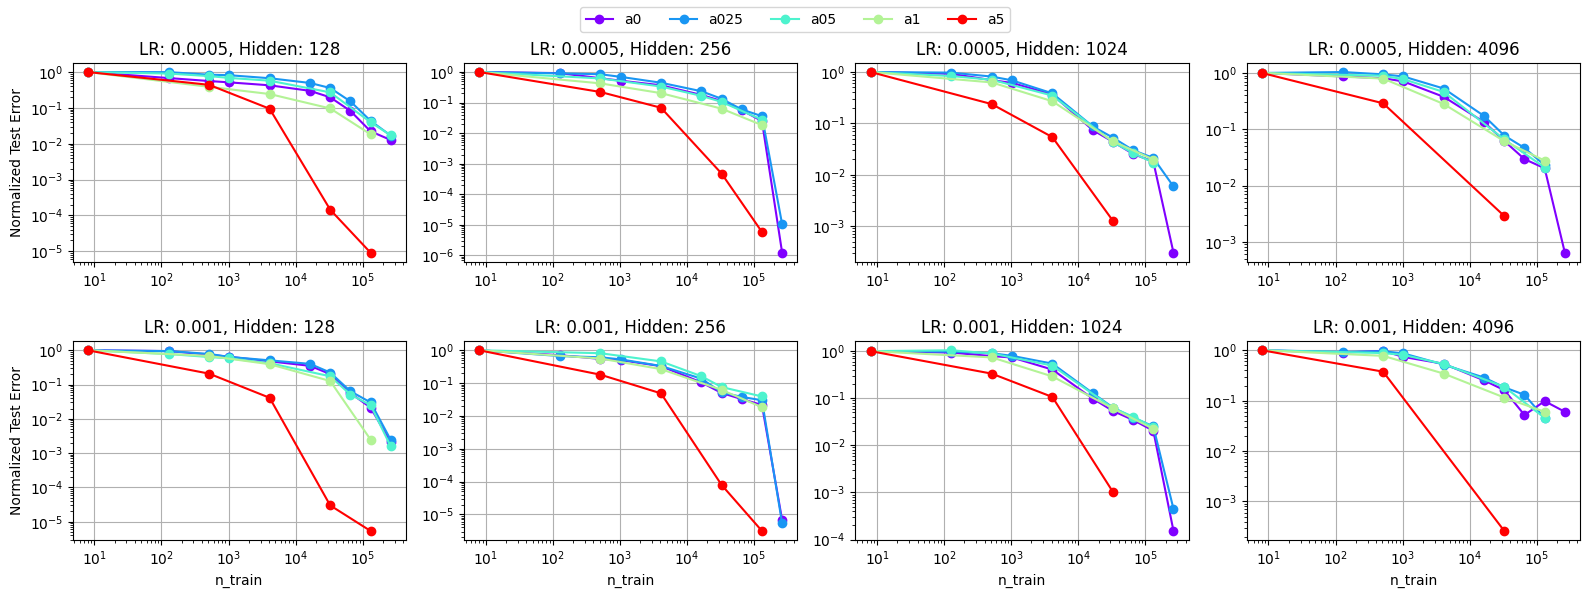

In [7]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the paths to your results directories
results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d16_uniform_hidden128_d2_standard_0103"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = ""  # e.g., "my_plot.png"

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load results
all_results = load_results(results_directory)

if not all_results:
    print("No results loaded. Please check the directory path.")

# ======= FILTER FOR SPECIFIC NETWORKS =======
# We'll filter by depth if needed
filtered_results = [r for r in all_results if r.get("depth") == 2]  # Using depth=2 as mentioned in the example

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from results
for r in filtered_results:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

unique_lr = sorted(lr_set)
unique_hidden = sorted(hidden_set)
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Filter for 'a' datasets

# We'll compare the first two learning rates
if len(unique_lr) >= 2:
    learning_rates_to_compare = unique_lr[:2]
    print(f"Comparing learning rates: {learning_rates_to_compare}")
else:
    learning_rates_to_compare = unique_lr
    print(f"Only one learning rate available: {learning_rates_to_compare}")

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 5 (assuming a0 to a5 range)
                position = min(1.0, max(0.0, num / 5.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a5 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group results
grouped_results = group_results(filtered_results)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row is a learning rate
n_rows = len(learning_rates_to_compare)
n_cols = len(unique_hidden)

# Catch the case where there's only one hidden size to prevent 1D array issues
if n_cols == 1:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 4 * n_rows), squeeze=False)
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(learning_rates_to_compare):
    for j, hs in enumerate(unique_hidden):
        # Get the appropriate axis
        ax = axes[i, j]
        
        # Plot data for this learning rate and hidden size
        data_dict = grouped_results[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from dataset colors
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # Set scales, labels, title
        ax.set_xscale("log")
        #ax.set_yscale("log")
        # Set y-scale to log if normalizing (to see power laws better)
        if normalize_errors:
            ax.set_yscale("log")
        
        ax.set_title(f"LR: {lr}, Hidden: {hs}")
        ax.grid(True)
        
        # Only add x-label to bottom row
        if i == len(learning_rates_to_compare) - 1:
            ax.set_xlabel("n_train")
        
        # Add y-label to leftmost column
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax.set_ylabel(y_label)

# Create a global legend above the subplots only if we have handles
if legend_handles:
    fig.legend(
        list(legend_handles.values()), 
        list(legend_handles.keys()), 
        loc="upper center", 
        ncol=min(len(legend_handles), 6)
    )

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4)  # Make room for the legend and between rows

if save_fig_path:
    plt.savefig(save_fig_path)
    print("Figure saved to", save_fig_path)
else:
    plt.show()